<a href="https://colab.research.google.com/github/argg1006/TRABAJOS/blob/main/EXAMENISI2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Precio promedio general
732.3514613499999

Precio promedio por ciudad
Lugar
Cotopaxi, Latacunga, Cotopaxi, Ecuador                 3697.685799
Cotopaxi, Latacunga, Ecuador                            118.854358
El Oro, El Cambio, Machala, Ecuador                     124.256523
El Oro, Parroquia El Cambio, Machala                    124.458032
Esmeraldas, Av. Club del Pacífico, Tonsupa, Ecuador     508.493561
Name: Precio, dtype: float64

Costo promedio por metro cuadrado
5.894463987006148

Rango de precios por provincia
                 min       max         mean
Provincia                                  
Cotopaxi       94.47   4557.66  1814.528859
El Oro         98.42    155.03   124.352068
Esmeraldas    111.33    620.53   327.772537
Guayas        130.85   2816.34   614.669888
Imbabura      380.54    589.42   480.809447
Los Rios      176.04    295.08   233.589620
Manabí       5176.48   7920.44  6503.102091
Orellana      118.86    185.84   149.863608
Pichincha      80.21  11062.33   73

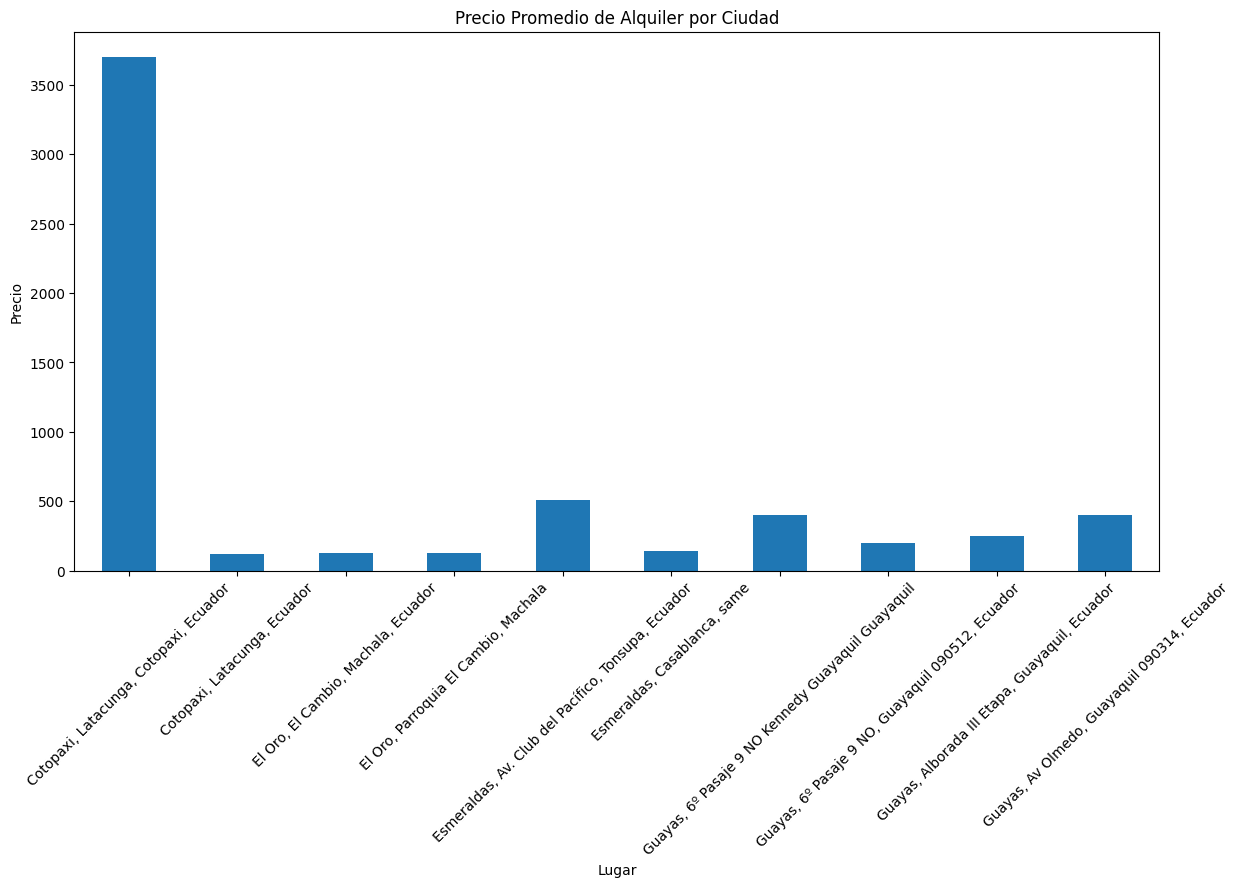

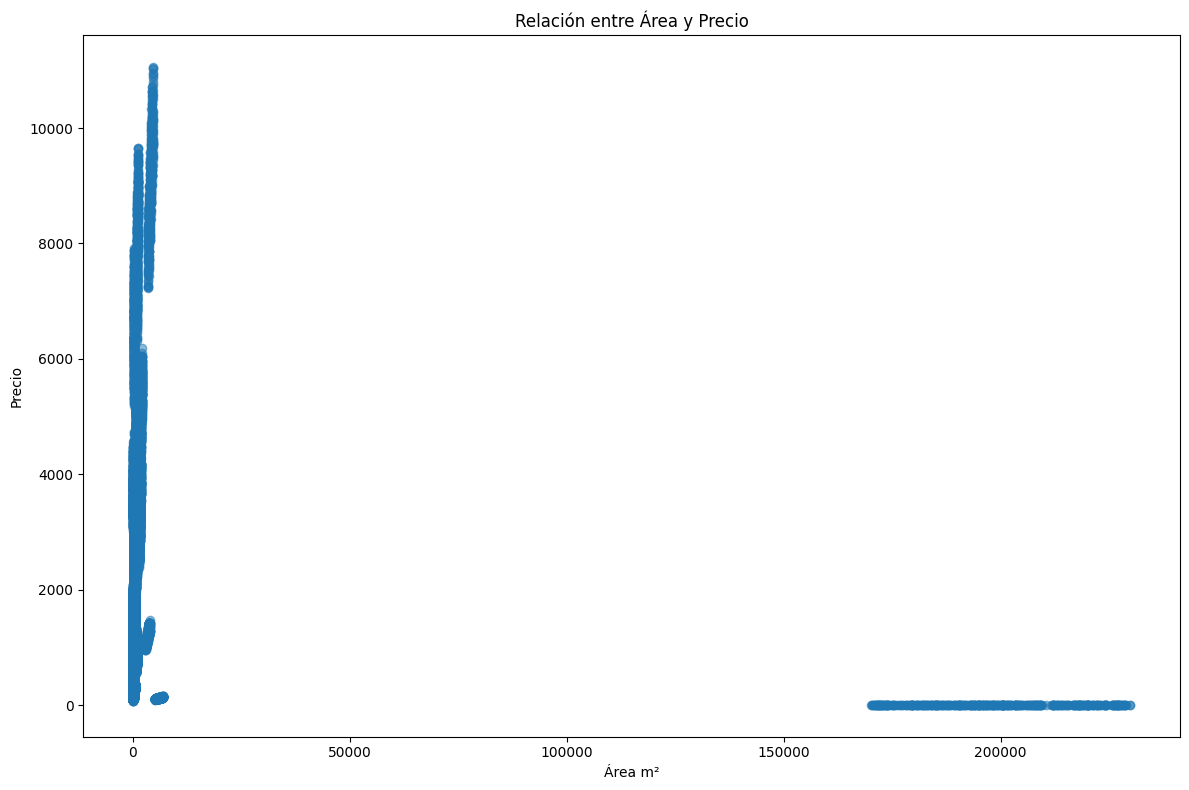

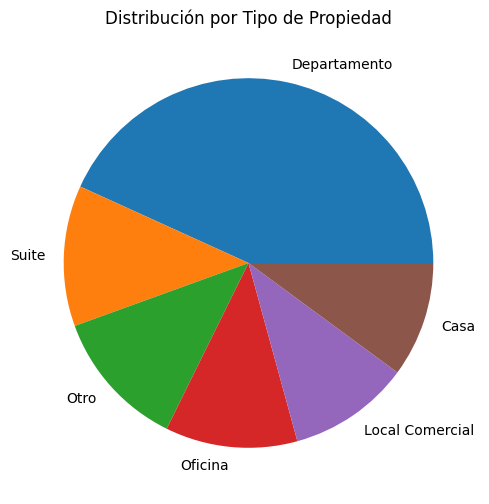

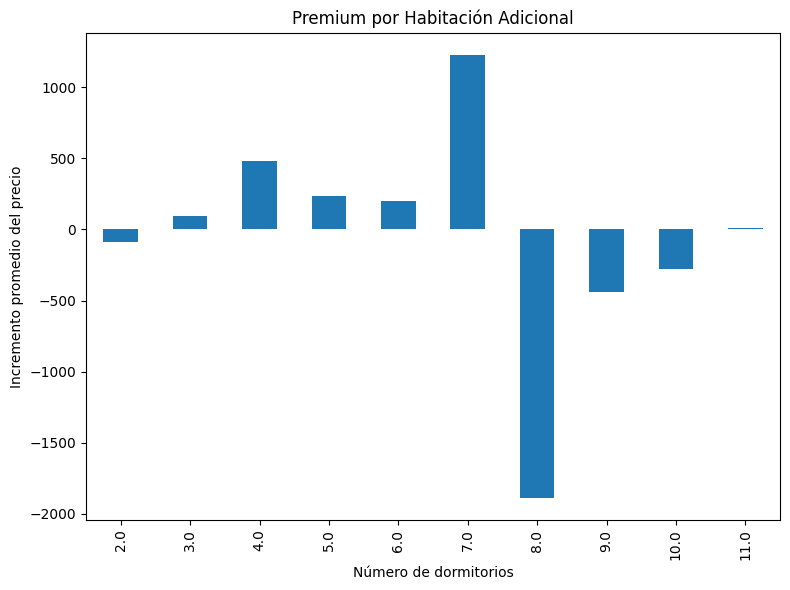

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("real_estate_ecuador_200k.csv")
df = df.dropna(subset=["Precio", "Area"])
columnas_numericas = ["Precio","Area","Num. dormitorios","Num. banos","Num. garages"]

for col in columnas_numericas:df[col] = pd.to_numeric(df[col], errors="coerce")

#1. PERSPECTIVA FINANCIERA

#1.1 Precio promedio general/Precio promedio por ciudad
precio_promedio_general = df["Precio"].mean()
print("Precio promedio general")
print(precio_promedio_general)
precio_promedio_ciudad = (df.groupby("Lugar")["Precio"].mean())
print()
print("Precio promedio por ciudad")
print(precio_promedio_ciudad.head())

#1.2 Costo promedio por metro cuadrado
df["Precio_m2"] = df["Precio"] / df["Area"]
costo_promedio_m2 = df["Precio_m2"].mean()
print()
print("Costo promedio por metro cuadrado")
print(costo_promedio_m2)

#1.3 Rango de precios por provincia
rango_provincia = (df.groupby("Provincia")["Precio"].agg(["min", "max", "mean"]))
print()
print("Rango de precios por provincia")
print(rango_provincia)

#2.PERSPECTIVA DE PRODUCTO

#2.1 Distribucion por tipo de propiedad
tipos = {"departamento": "Departamento","suite": "Suite","casa": "Casa","local": "Local Comercial","oficina": "Oficina"}
def obtener_tipo(titulo):
    titulo = str(titulo).lower()
    for palabra, tipo in tipos.items():
        if palabra in titulo:
            return tipo
    return "Otro"
df["Tipo_Propiedad"] = df["Titulo"].apply(obtener_tipo)
conteo_tipo = df["Tipo_Propiedad"].value_counts()
print()
print("Distribucion por producto")
print(conteo_tipo)

#2.2 Tamaño promedio por provincia
tamano_promedio = (df.groupby("Provincia")["Area"].mean())
print()
print("Tamaño promedio por provincia")
print(tamano_promedio)

#2.3 Premium por habitación adicional
precio_por_habitacion = (df.groupby("Num. dormitorios")["Precio"].mean().sort_index())
premium = precio_por_habitacion.diff()
print()
print("premium por habitacion adicional")
print(premium)

#3 PERSPECTIVA GEOGRAFICA
#3.1 Top 5 ciudades más caras
top = (df.groupby("Lugar")["Precio"].mean().sort_values(ascending=False).head(5))
print()
print("Top 5 ciudades más caras")
print(top)

#3.2 Concentración de oferta
oferta_provincia = df["Provincia"].value_counts()
print()
print("Concetracion de oferta")
print(oferta_provincia)

#4 SEGMENTACION DE MERCADO

q1 = df["Precio"].quantile(0.25)
q3 = df["Precio"].quantile(0.75)

def segmentar(precio):
    if precio < q1:
        return "Económico"
    elif precio > q3:
        return "Lujo"
    else:
        return "Medio"

df["Tipo_Inmueble"] = df["Precio"].apply(segmentar)

print("Tipo de inmueble")
print(df["Tipo_Inmueble"].value_counts())

#DASHBOARDS
#1. TOTAL DE PROPIEDADES
print("total de propiedades")
print(len(df))

#2.GRAFICO DE BARRAS DE PRECIO PROMEDIO DE ALQUILER
plt.figure(figsize=(14,7))
precio_promedio_ciudad.head(10).plot(kind="bar")
plt.title("Precio Promedio de Alquiler por Ciudad")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.show()


# GRAFICO DE DISPERSION ENTRE AREA Y PRECIO
plt.figure(figsize=(12,8))
plt.scatter(df["Area"], df["Precio"], alpha=0.5)
plt.xlabel("Área m²")
plt.ylabel("Precio")
plt.title("Relación entre Área y Precio")
plt.tight_layout()
plt.show()



# TIPO DE PROPIEDAD
conteo_tipo.plot(kind='pie', figsize=(8,6))
plt.ylabel('')
plt.title('Distribución por Tipo de Propiedad')
plt.show()

# PREMIUM POR HABITACION

plt.figure(figsize=(8,6))
premium.dropna().plot(kind="bar")
plt.title("Premium por Habitación Adicional")
plt.xlabel("Número de dormitorios")
plt.ylabel("Incremento promedio del precio")
plt.tight_layout()
plt.show()

